In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

In [3]:
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
  
# metadata 
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata) 
  
# variable information 
print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 

{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [4]:
ids = diabetes_130_us_hospitals_for_years_1999_2008.data.ids
temp = ids.join(X)
df = temp.join(y)

In [ ]:
# save dataframe with original data
df.to_csv('original_data.csv')

In [5]:
print(df.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [6]:
print(df.groupby('weight').size())

weight
>200            3
[0-25)         48
[100-125)     625
[125-150)     145
[150-175)      35
[175-200)      11
[25-50)        97
[50-75)       897
[75-100)     1336
dtype: int64


In [7]:
# most common admitting medical specialties
df['medical_specialty'].value_counts(dropna=False)

medical_specialty
NaN                              49949
InternalMedicine                 14635
Emergency/Trauma                  7565
Family/GeneralPractice            7440
Cardiology                        5352
                                 ...  
SportsMedicine                       1
Speech                               1
Perinatology                         1
Neurophysiology                      1
Pediatrics-InfectiousDiseases        1
Name: count, Length: 73, dtype: int64

In [8]:
# find number of missing values for each column with missing values + overall percentage missing

# number of rows
n_rows = df.shape[0]
# column names 
columns = df.columns
col_percent_missing = []

# calculate percentage of missing values for each column 
for col in columns:
    col_na = df[col].isna().sum()
    col_percent = (col_na/n_rows)*100
    col_percent_missing.append((col, col_percent))

col_to_drop = []

# print columns with missing values
for col in col_percent_missing:
    if (col[1] > 0):
        print(f'{col[0]}: {col[1]:.2f}% missing')
        if (col[1] > 75):
            col_to_drop.append(col[0])


race: 2.23% missing
weight: 96.86% missing
payer_code: 39.56% missing
medical_specialty: 49.08% missing
diag_1: 0.02% missing
diag_2: 0.35% missing
diag_3: 1.40% missing
max_glu_serum: 94.75% missing
A1Cresult: 83.28% missing


In [9]:
# drop columns with > 75% missing values
df_new = df.drop(columns=col_to_drop)

In [10]:
# drop columns that are not needed for model prediction
drop_col = ['payer_code', 'num_lab_procedures']
df_temp = df_new.drop(columns=drop_col)

In [11]:
# remove rows with missing race and diagnosis information
df_updated = df_temp.dropna(subset = ['race', 'diag_1', 'diag_2', 'diag_3'])

In [12]:
# check for duplicate rows 
ids['encounter_id'].duplicated().any()

np.False_

In [13]:
# check for inconsistencies in data formatting (inconsistent capitalization, spacing, etc)
for col in df_updated.columns:
    print(df_updated[col].value_counts(dropna=False))

encounter_id
149190       1
191187564    1
191236368    1
191234376    1
191224722    1
            ..
108144486    1
108143628    1
108143292    1
108141846    1
443867222    1
Name: count, Length: 98053, dtype: int64
patient_nbr
88785891     39
1660293      23
88227540     23
23199021     23
23643405     22
             ..
24538824      1
4478517       1
23232438      1
29049372      1
175429310     1
Name: count, Length: 68630, dtype: int64
race
Caucasian          75079
AfricanAmerican    18881
Hispanic            1984
Other               1484
Asian                625
Name: count, dtype: int64
gender
Female             52833
Male               45219
Unknown/Invalid        1
Name: count, dtype: int64
age
[70-80)     25306
[60-70)     21809
[80-90)     16702
[50-60)     16697
[40-50)      9265
[30-40)      3548
[90-100)     2717
[20-30)      1478
[10-20)       466
[0-10)         65
Name: count, dtype: int64
admission_type_id
1    52178
3    18194
2    17543
6     5135
5     4661
8    

In [14]:
# remove one row with unknown gender value
df_updated.drop(df_updated[df_updated['gender'] == 'Unknown/Invalid'].index, inplace=True)

/var/folders/mh/40c656wd7r33_mswpgt_nng00000gn/T/ipykernel_71900/2722962567.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_updated.drop(df_updated[df_updated['gender'] == 'Unknown/Invalid'].index, inplace=True)


In [15]:
# remove null/unknown values from numerically mapped columns 

# admission - remove 5, 6, 8
df_updated = df_updated[~df_updated['admission_type_id'].isin([5, 6, 8])]

# discharge - remove 18, 25, 26
df_updated = df_updated[~df_updated['discharge_disposition_id'].isin([18, 25, 26])]

# admission source - remove 9, 15, 17, 20, 21  
df_updated = df_updated[~df_updated['admission_source_id'].isin([9, 15, 17, 20, 21])]

In [16]:
# change readmitted to binary values, where < 30 readmission is 1, otherwise 0

import numpy as np
df_updated['readmitted'] = np.where(df_updated['readmitted'] == '<30', 1, 0) 

In [17]:
df_updated['readmitted'].value_counts(dropna=False)

readmitted
0    73857
1     9397
Name: count, dtype: int64

In [18]:
# create new features 

# create col for total hospitalizations 
df_updated['num_hospitalizations'] = df_updated.groupby('patient_nbr')['patient_nbr'].transform('count')

# procedures/length of stay
df_updated['avg_procedure'] = df_updated['num_procedures'] / df_updated['time_in_hospital'] 

# number of total visits
df_updated['total_visits'] = df_updated['number_outpatient'] + df_updated['number_emergency'] + df_updated['number_inpatient']

# number of med changes 
df_updated['num_med_changes'] = df_updated.loc[:, 'metformin':'metformin-pioglitazone'].isin(['Down', 'Up']).sum(axis=1)

# number of med increases 
df_updated['num_med_increase'] = df_updated.loc[:, 'metformin':'metformin-pioglitazone'].isin(['Up']).sum(axis=1)

In [19]:
# drop columns not needed for model prediction

df_final = df_updated.drop(columns=df_updated.loc[:, 'metformin':'metformin-pioglitazone'].columns)
df_final = df_final.drop(columns=['medical_specialty', 'encounter_id', 'patient_nbr'])
df_final.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'change', 'diabetesMed', 'readmitted',
       'num_hospitalizations', 'avg_procedure', 'total_visits',
       'num_med_changes', 'num_med_increase'],
      dtype='object')

In [20]:
# create boolean values for 'change' and 'diabetesMed' columns 
df_final['change'] = np.where(df_updated['change'] == 'Ch', 1, 0) 
df_final['diabetesMed'] = np.where(df_updated['diabetesMed'] == 'Yes', 1, 0) 

In [21]:
df_final.head(10)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_procedures,num_medications,number_outpatient,...,diag_3,number_diagnoses,change,diabetesMed,readmitted,num_hospitalizations,avg_procedure,total_visits,num_med_changes,num_med_increase
1,Caucasian,Female,[10-20),1,1,7,3,0,18,0,...,255,9,1,1,0,1,0.000000,0,1,1
2,AfricanAmerican,Female,[20-30),1,1,7,2,5,13,2,...,V27,6,0,1,0,1,2.500000,3,0,0
3,Caucasian,Male,[30-40),1,1,7,2,1,16,0,...,403,7,1,1,0,1,0.500000,0,1,1
4,Caucasian,Male,[40-50),1,1,7,1,0,8,0,...,250,5,1,1,0,1,0.000000,0,0,0
5,Caucasian,Male,[50-60),2,1,2,3,6,16,0,...,250,9,0,1,0,1,2.000000,0,0,0
6,Caucasian,Male,[60-70),3,1,2,4,1,21,0,...,V45,7,1,1,0,1,0.250000,0,0,0
7,Caucasian,Male,[70-80),1,1,7,5,0,12,0,...,250,8,0,1,0,1,0.000000,0,0,0
8,Caucasian,Female,[80-90),2,1,4,13,2,28,0,...,38,8,1,1,0,1,0.153846,0,0,0
9,Caucasian,Female,[90-100),3,3,4,12,3,18,0,...,486,8,1,1,0,1,0.250000,0,0,0
10,AfricanAmerican,Female,[40-50),1,1,7,9,2,17,0,...,996,9,0,1,0,1,0.222222,0,0,0


In [60]:
# save processed dataframe 
df_final.to_csv('final_data.csv')

In [22]:
icd_data = pd.read_json('icd_codes.json')

In [23]:
icd_data

,code,desc,children
0,00-00,"Procedures And Interventions , Not Elsewhere C...","[{'code': '00', 'desc': 'Procedures And Interv..."
1,01-05,Operations On The Nervous System,"[{'code': '01', 'desc': 'Incision And Excision..."
2,06-07,Operations On The Endocrine System,"[{'code': '06', 'desc': 'Operations On Thyroid..."
3,08-16,Operations On The Eye,"[{'code': '08', 'desc': 'Operations On Eyelids..."
4,17-17,Other Miscellaneous Diagnostic And Therapeutic...,"[{'code': '17', 'desc': 'Other Miscellaneous P..."
5,18-20,Operations On The Ear,"[{'code': '18', 'desc': 'Operations On Externa..."
6,21-29,"Operations On The Nose, Mouth, And Pharynx","[{'code': '21', 'desc': 'Operation On Nose', '..."
7,30-34,Operations On The Respiratory System,"[{'code': '30', 'desc': 'Excision Of Larynx', ..."
8,35-39,Operations On The Cardiovascular System,"[{'code': '35', 'desc': 'Operations On Valves ..."
9,40-41,Operations On The Hemic And Lymphatic System,"[{'code': '40', 'desc': 'Operations On Lymphat..."


In [24]:
# load in icd code data
import json
with open('icd_codes.json') as file:
    icd_raw_data = json.load(file)

In [25]:
# test line to see how data is organized 
record = icd_raw_data[0]
print(record.get('children')[0].get('children')[0])

{'code': '00.0', 'desc': 'Therapeutic Ultrasound', 'children': [{'code': '00.01', 'desc': 'Therapeutic ultrasound of vessels of head and neck', 'children': []}, {'code': '00.02', 'desc': 'Therapeutic ultrasound of heart', 'children': []}, {'code': '00.03', 'desc': 'Therapeutic ultrasound of peripheral vascular vessels', 'children': []}, {'code': '00.09', 'desc': 'Other therapeutic ultrasound', 'children': []}]}


In [26]:
# extract icd data from nested format

icd_data = []

for category in icd_raw_data:
    primary_category = category.get('desc')
    sub_categories = category.get('children')
    for sub_category in sub_categories:
        sub_category_desc = sub_category.get('desc')
        codes = sub_category.get('children')
        for value in codes:
            code = value.get('code')
            code_desc = value.get('desc')
            icd_data.append({'code': code, 'description': code_desc, 'primary_category': primary_category, 'subcategory': sub_category_desc})

In [27]:
# save icd data to dataframe 
icd_code_df = pd.DataFrame(icd_data)

In [44]:
# export icd_dataframe 
icd_code_df.to_csv('icd_code.csv')

In [29]:
print(df_final[['admission_type_id', 'discharge_disposition_id', 'admission_source_id']].dtypes)

admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
dtype: object


In [31]:
print(df_final['diag_1'].value_counts().head(20))

diag_1
428      5717
414      5395
786      3155
410      2910
486      2860
427      2273
491      1905
434      1720
780      1668
996      1659
682      1647
715      1637
276      1558
38       1433
599      1385
250.8    1372
584      1288
250.6    1022
518       933
V57       924
Name: count, dtype: int64


In [32]:
print(icd_code_df['code'].head(20))

0     00.0
1     00.1
2     00.2
3     00.3
4     00.4
5     00.5
6     00.6
7     00.7
8     00.8
9     00.9
10    01.0
11    01.1
12    01.2
13    01.3
14    01.4
15    01.5
16    01.6
17    02.0
18    02.1
19    02.2
Name: code, dtype: object


In [33]:
icd_code_df = pd.read_csv('icd_code.csv')
print(icd_code_df.columns.tolist())
print(icd_code_df.head())

['Unnamed: 0', 'code', 'description', 'primary_category', 'subcategory']
   Unnamed: 0  code                             description  \
0           0  00.0                  Therapeutic Ultrasound   
1           1  00.1                         Pharmaceuticals   
2           2  00.2  Intravascular Imaging Of Blood Vessels   
3           3  00.3         Computer Assisted Surgery (Cas)   
4           4  00.4      Adjunct Vascular System Procedures   

                                    primary_category  \
0  Procedures And Interventions , Not Elsewhere C...   
1  Procedures And Interventions , Not Elsewhere C...   
2  Procedures And Interventions , Not Elsewhere C...   
3  Procedures And Interventions , Not Elsewhere C...   
4  Procedures And Interventions , Not Elsewhere C...   

                                         subcategory  
0  Procedures And Interventions, Not Elsewhere Cl...  
1  Procedures And Interventions, Not Elsewhere Cl...  
2  Procedures And Interventions, Not Elsewhere

In [ ]:
# only need code and primary category for merging with diag columns
icd_lookup = icd_code_df[['code', 'primary_category']].drop_duplicates(subset='code')

# strip decimal from diag columns to standardize and match CSV format
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_final[col] = df_final[col].astype(str).str.split('.').str[0].str.strip()

# standardize the code column too
icd_lookup['code'] = icd_lookup['code'].astype(str).str.strip()

# merge for each diag column
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_final = df_final.merge(
        icd_lookup.rename(columns={'code': col, 'primary_category': f'{col}_category'}),
        on=col,
        how='left'
    )
    df_final[f'{col}_category'] = df_final[f'{col}_category'].fillna('Other')
    df_final = df_final.drop(columns=[col])

print(df_final['diag_1_category'].value_counts())

diag_1_category
Diseases Of The Circulatory System                                                                    25029
Endocrine, Nutritional And Metabolic Diseases, And Immunity Disorders                                  8965
Diseases Of The Respiratory System                                                                     8557
Diseases Of The Digestive System                                                                       7532
Symptoms, Signs, And Ill-Defined Conditions                                                            6187
Injury And Poisoning                                                                                   5780
Diseases Of The Genitourinary System                                                                   4294
Diseases Of The Musculoskeletal System And Connective Tissue                                           3915
Other                                                                                                  3253
Neoplasms   

## Data Modeling

In [ ]:
# encode categorical variables for modeling
df_model = pd.get_dummies(df_final, columns=['race', 'gender', 'age', 'diag_1_category', 'diag_2_category', 'diag_3_category'], drop_first=True)
df_model.head(5)

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,diag_3_category_Diseases Of The Skin And Subcutaneous Tissue,"diag_3_category_Endocrine, Nutritional And Metabolic Diseases, And Immunity Disorders",diag_3_category_Infectious And Parasitic Diseases,diag_3_category_Injury And Poisoning,diag_3_category_Mental Disorders,diag_3_category_Neoplasms,diag_3_category_Other,diag_3_category_Supplementary Classification Of External Causes Of Injury And Poisoning,diag_3_category_Supplementary Classification Of Factors Influencing Health Status And Contact With Health Services,"diag_3_category_Symptoms, Signs, And Ill-Defined Conditions"
0,1,1,7,3,0,18,0,0,0,9,...,False,True,False,False,False,False,False,False,False,False
1,1,1,7,2,5,13,2,0,1,6,...,False,False,False,False,False,False,False,False,True,False
2,1,1,7,2,1,16,0,0,0,7,...,False,False,False,False,False,False,False,False,False,False
3,1,1,7,1,0,8,0,0,0,5,...,False,True,False,False,False,False,False,False,False,False
4,2,1,2,3,6,16,0,0,0,9,...,False,True,False,False,False,False,False,False,False,False


In [56]:
X = df_model.drop(columns=['readmitted'])
y = df_model['readmitted']

print(y.value_counts())

readmitted
0    73857
1     9397
Name: count, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Training size: (66603, 79)
Test size: (16651, 79)


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression done")

Logistic Regression done


In [71]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest done")

Random Forest done


In [61]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
print("Gradient Boosting done")

Gradient Boosting done


In [75]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

gb_preds = gb.predict(X_test)
gb_probs = gb.predict_proba(X_test)[:, 1]

In [76]:
print("Logistic Regression")
print(classification_report(y_test, lr_preds))

print("Random Forest")
print(classification_report(y_test, rf_preds))

print("Gradient Boosting")
print(classification_report(y_test, gb_preds))

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     14772
           1       0.45      0.04      0.07      1879

    accuracy                           0.89     16651
   macro avg       0.67      0.52      0.50     16651
weighted avg       0.84      0.89      0.84     16651

Random Forest
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     14772
           1       0.50      0.02      0.03      1879

    accuracy                           0.89     16651
   macro avg       0.69      0.51      0.49     16651
weighted avg       0.84      0.89      0.84     16651

Gradient Boosting
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     14772
           1       0.48      0.02      0.04      1879

    accuracy                           0.89     16651
   macro avg       0.69      0.51      0.49     16651
weighted avg       0.8

In [77]:
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
gb_auc = roc_auc_score(y_test, gb_probs)

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC:       {rf_auc:.4f}")
print(f"Gradient Boosting AUC:   {gb_auc:.4f}")

Logistic Regression AUC: 0.7022
Random Forest AUC:       0.7551
Gradient Boosting AUC:   0.7760


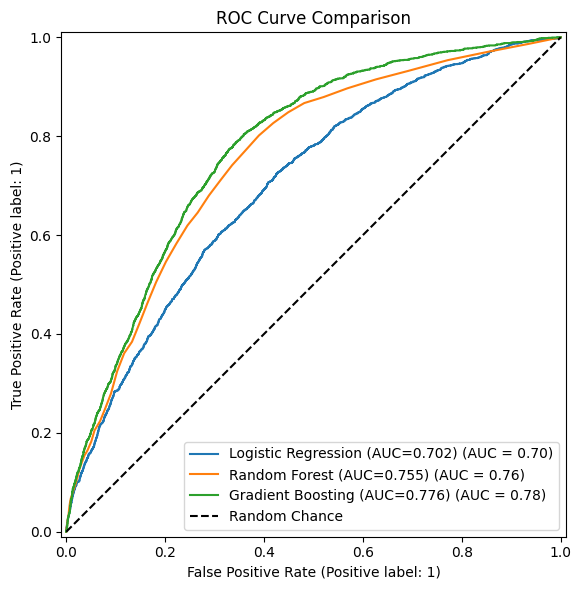

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_probs, name=f"Logistic Regression (AUC={lr_auc:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_probs, name=f"Random Forest (AUC={rf_auc:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, gb_probs, name=f"Gradient Boosting (AUC={gb_auc:.3f})", ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random Chance')
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()

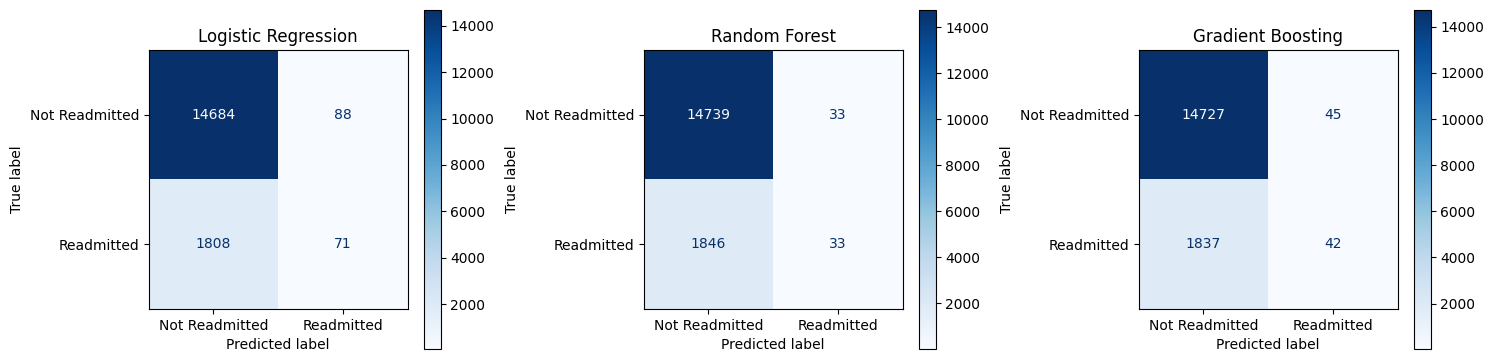

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logistic Regression
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('Logistic Regression')

# Random Forest
cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title('Random Forest')

# Gradient Boosting
cm = confusion_matrix(y_test, gb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[2])
axes[2].set_title('Gradient Boosting')

plt.tight_layout()
plt.show()

### Version 2: Fix the class imbalance between not readmitted and readmitted

In [79]:
from sklearn.utils.class_weight import compute_sample_weight

lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)

rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)

gb_balanced = GradientBoostingClassifier(n_estimators=100, random_state=42)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb_balanced.fit(X_train, y_train, sample_weight=sample_weights)

print("Balanced models trained!")

Balanced models trained!


In [80]:
lr_balanced_preds = lr_balanced.predict(X_test_scaled)
lr_balanced_probs = lr_balanced.predict_proba(X_test_scaled)[:, 1]

rf_balanced_preds = rf_balanced.predict(X_test)
rf_balanced_probs = rf_balanced.predict_proba(X_test)[:, 1]

gb_balanced_preds = gb_balanced.predict(X_test)
gb_balanced_probs = gb_balanced.predict_proba(X_test)[:, 1]

print("Balanced Logistic Regression")
print(classification_report(y_test, lr_balanced_preds))

print("Balanced Random Forest")
print(classification_report(y_test, rf_balanced_preds))

print("Balanced Gradient Boosting")
print(classification_report(y_test, gb_balanced_preds))

lr_balanced_auc = roc_auc_score(y_test, lr_balanced_probs)
rf_balanced_auc = roc_auc_score(y_test, rf_balanced_probs)
gb_balanced_auc = roc_auc_score(y_test, gb_balanced_probs)

print(f"Balanced Logistic Regression AUC: {lr_balanced_auc:.4f}")
print(f"Balanced Random Forest AUC:       {rf_balanced_auc:.4f}")
print(f"Balanced Gradient Boosting AUC:   {gb_balanced_auc:.4f}")

Balanced Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.75      0.83     14772
           1       0.22      0.54      0.31      1879

    accuracy                           0.73     16651
   macro avg       0.57      0.65      0.57     16651
weighted avg       0.85      0.73      0.77     16651

Balanced Random Forest
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     14772
           1       0.57      0.02      0.03      1879

    accuracy                           0.89     16651
   macro avg       0.73      0.51      0.49     16651
weighted avg       0.85      0.89      0.84     16651

Balanced Gradient Boosting
              precision    recall  f1-score   support

           0       0.96      0.66      0.78     14772
           1       0.23      0.78      0.35      1879

    accuracy                           0.67     16651
   macro avg       0.59      0.72      0.57     1

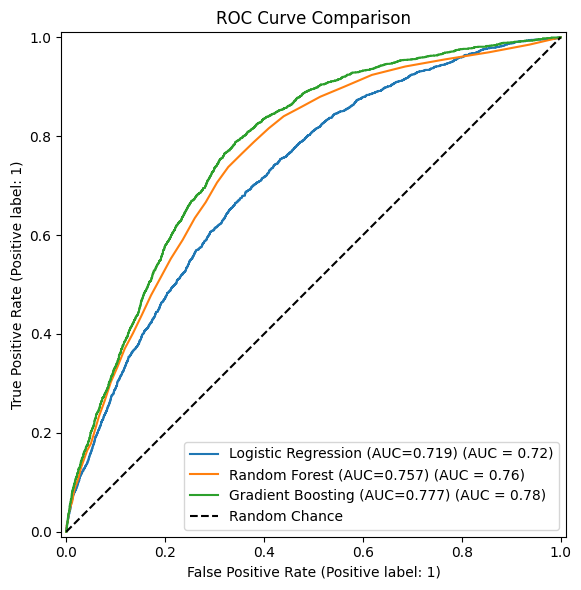

In [81]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_balanced_probs, name=f"Logistic Regression (AUC={lr_balanced_auc:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_balanced_probs, name=f"Random Forest (AUC={rf_balanced_auc:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, gb_balanced_probs, name=f"Gradient Boosting (AUC={gb_balanced_auc:.3f})", ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random Chance')
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()

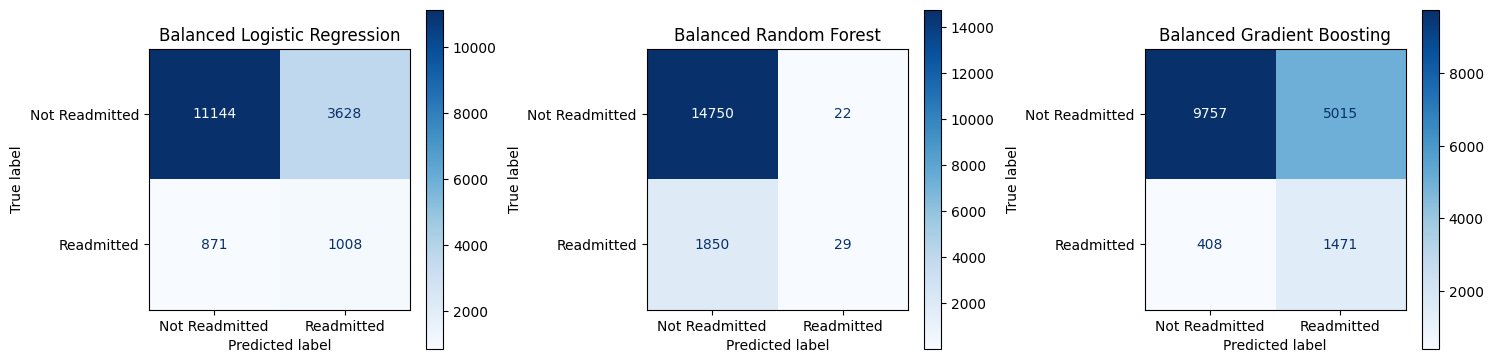

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Balanced Logistic Regression
cm = confusion_matrix(y_test, lr_balanced_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('Balanced Logistic Regression')

# Balanced Random Forest
cm = confusion_matrix(y_test, rf_balanced_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title('Balanced Random Forest')

# Balanced Gradient Boosting
cm = confusion_matrix(y_test, gb_balanced_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues, ax=axes[2])
axes[2].set_title('Balanced Gradient Boosting')

plt.tight_layout()
plt.show()

### Hyperparameter tuning of the gradient boosting model

In [83]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}

In [84]:
gb_tuned = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

gb_tuned.fit(X_train, y_train, sample_weight=sample_weights_train)

print("Best parameters:", gb_tuned.best_params_)
print("Best AUC score:", gb_tuned.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 4, 'learning_rate': 0.05}
Best AUC score: 0.7857326489552816


In [86]:
gb_best = gb_tuned.best_estimator_

gb_tuned_preds = gb_best.predict(X_test)
gb_tuned_probs = gb_best.predict_proba(X_test)[:, 1]

print("Tuned Gradient Boosting")
print(classification_report(y_test, gb_tuned_preds))
print(f"Tuned Gradient Boosting AUC: {roc_auc_score(y_test, gb_tuned_probs):.4f}")

Tuned Gradient Boosting
              precision    recall  f1-score   support

           0       0.96      0.66      0.78     14772
           1       0.23      0.78      0.35      1879

    accuracy                           0.67     16651
   macro avg       0.59      0.72      0.57     16651
weighted avg       0.88      0.67      0.73     16651

Tuned Gradient Boosting AUC: 0.7803


## Explainable AI (SHAP)

In [89]:
import sys
!{sys.executable} -m pip install shap

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.3/562.3 kB 11.5 MB/s eta 0:00:00a 0:00:01
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 69.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 63.3 MB/s eta 0:00:0000:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip


In [90]:
import shap

explainer = shap.TreeExplainer(gb_best)
shap_values = explainer.shap_values(X_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


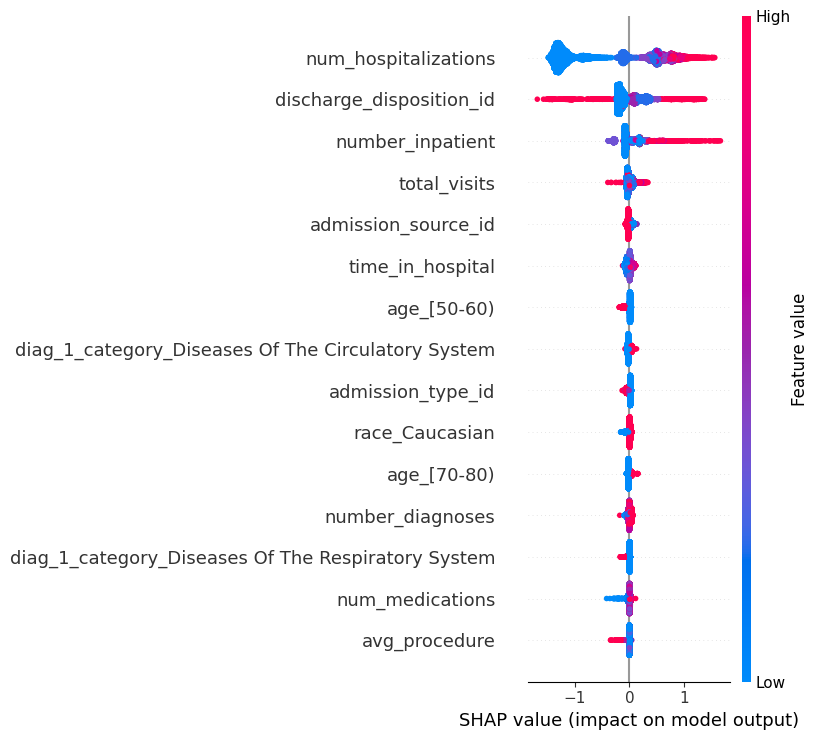

In [ ]:
# Summary dot plot
shap.summary_plot(shap_values, X_test, max_display=15)

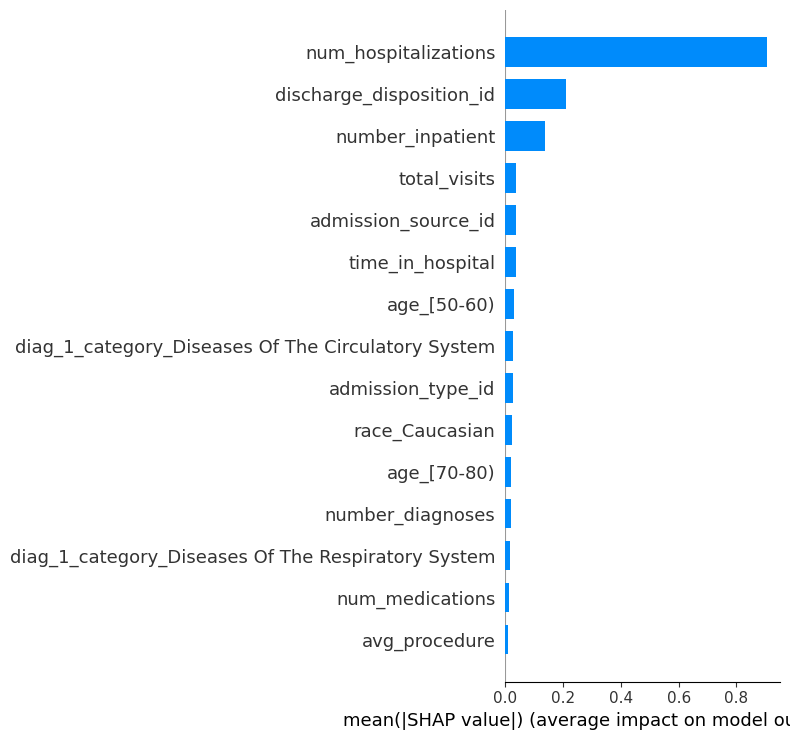

In [ ]:
# Summary bar chart
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15)

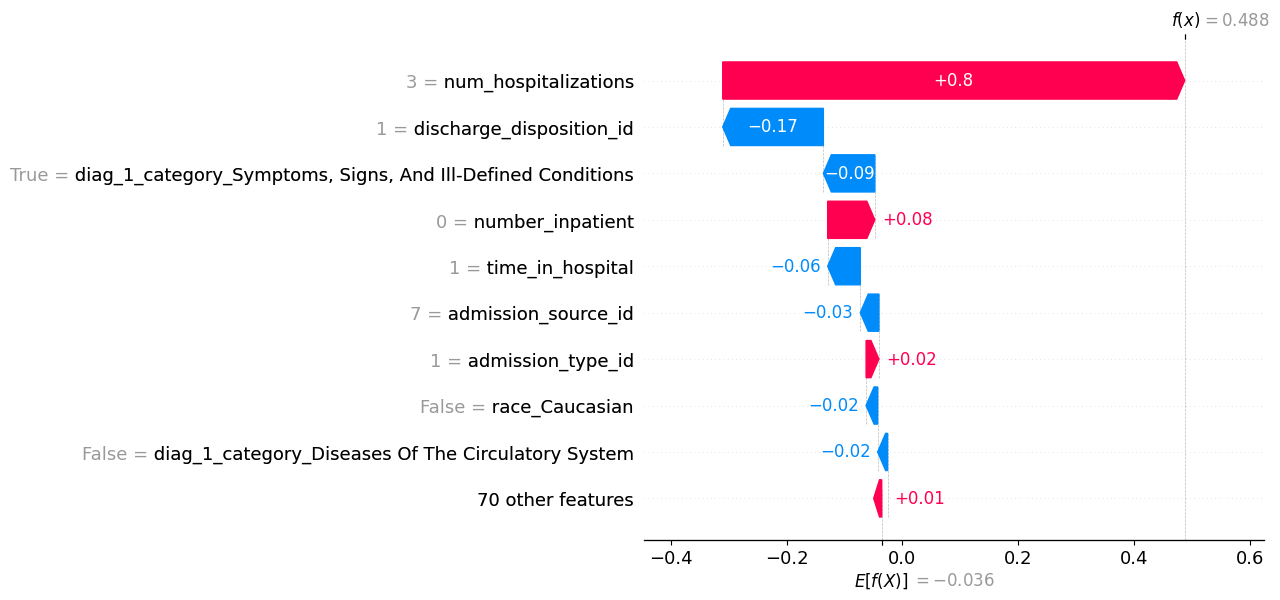

In [ ]:
# Waterfall plot - explains the reasoning for the first patient in the test set
shap.plots.waterfall(explainer(X_test)[0])